#Home Appliance Power Consumption Classification

**Course:** TSAC 2025/2026

**Goal:** The goal is to classify power consumption recordings into one of 10 home appliance categories.



---



# Problem Understanding


---

## Overview

This notebook tackles a **multiclass time series classification** problem.  
Given a recording of power consumption over time, we need to identify which home appliance produced it.

There are **10 appliance classes**:

| Label | Appliance |
|-------|-----------|
| 0 | Mobile phone chargers |
| 1 | Coffee machines |
| 2 | Computer stations (incl. monitor) |
| 3 | Fridges & freezers |
| 4 | Hi-Fi systems (CD players) |
| 5 | CFL Lamps |
| 6 | Laptops (via chargers) |
| 7 | Microwave ovens |
| 8 | Printers |
| 9 | Televisions (LCD/LED) |

---

## Our Approach

We treat this as a **feature-based classification** problem. Rather than feeding the raw 1460-point time series directly into a classifier (which would create a very high-dimensional and noisy input), we extract meaningful **statistical and structural features** from each series, then train classical ML classifiers on those features.

We tested four models : Random Forest, SVM, k-NN with DTW, and ROCKET
 submitting each to Kaggle independently to compare real test accuracy.  
ROCKET achieved the highest score (0.90) and was selected as our final model.





---



# 1. Setup & Imports

In [ ]:
!pip install aeon dtaidistance tslearn --quiet

In [2]:
import os, sys, time, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Signal processing (for feature extraction)
from scipy.stats import skew, kurtosis
from scipy.signal import find_peaks

from dtaidistance import dtw
from collections import Counter

from tslearn.neighbors import KNeighborsTimeSeriesClassifier
from tslearn.metrics import dtw as tslearn_dtw

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("done")

done


#2. Data
##2.1 Loading

this cell added for the teacher to run it directly from the drive folder

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Path to the shared project folder — all files are in the same directory
PROJECT_PATH = '/content/drive/MyDrive/TSAC_Group_Project/'

train_df = pd.read_csv(PROJECT_PATH + 'train.csv', header=None)
test_df  = pd.read_csv(PROJECT_PATH + 'test.csv')

In [4]:

y_train  = train_df.iloc[:, 0].values
X_train  = train_df.iloc[:, 1:].values   # (100, 1460)
test_ids = test_df.iloc[:, 0].values
X_test   = test_df.iloc[:, 1:].values    # (100, 1460)

# aeon needs (n_samples, n_channels, n_timesteps)
X_train_3d = X_train.reshape(100, 1, 1460)
X_test_3d  = X_test.reshape(100, 1, 1460)

class_names = [
    'Phone charger', 'Coffee machine', 'Computer station', 'Fridge/Freezer',
    'Hi-Fi system', 'CFL Lamp', 'Laptop charger', 'Microwave', 'Printer', 'Television'
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Classes: {np.unique(y_train)} | Samples per class: 10 each")
print("Missing values (train):", np.isnan(X_train).sum())
print("Missing values (test): ", np.isnan(X_test).sum())

Train: (100, 1460) | Test: (100, 1460)
Classes: [0 1 2 3 4 5 6 7 8 9] | Samples per class: 10 each
Missing values (train): 0
Missing values (test):  0


##2.2 Visual Example

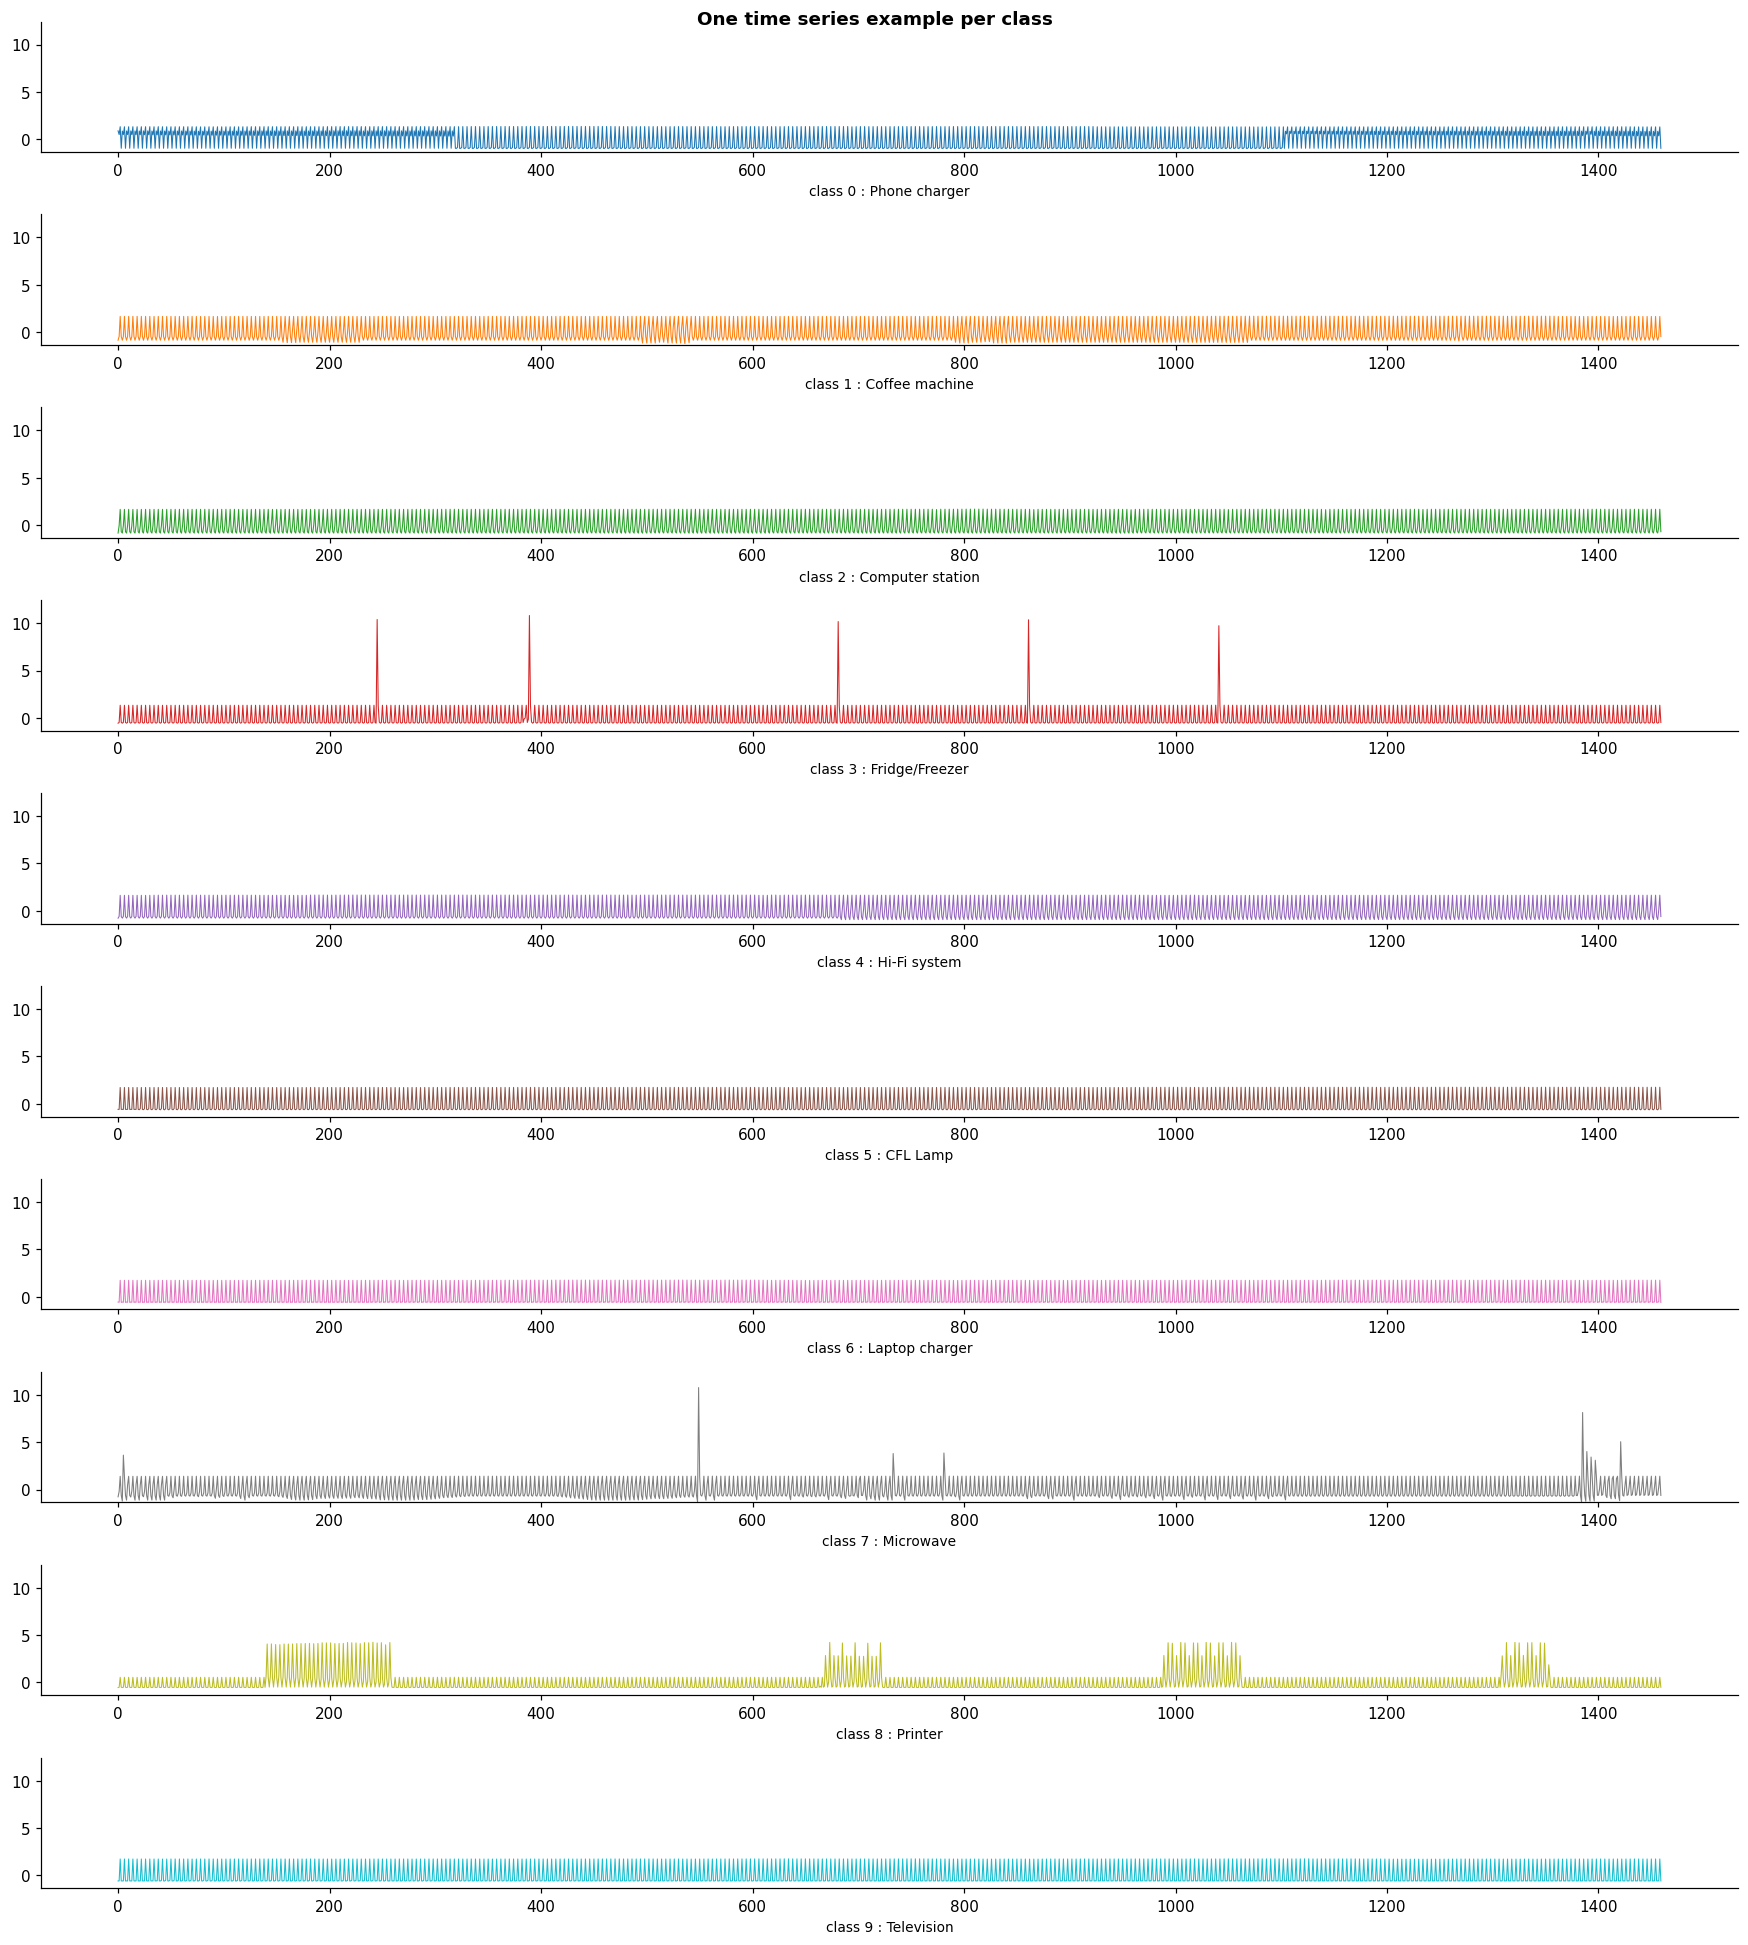

In [5]:
fig, axes = plt.subplots(10, 1, figsize=(16, 18), sharex=False)

for s in range(10):
    idx = np.where(y_train == s)[0][0]
    axes[s].plot(X_train[idx], lw=0.7, color=f'C{s}')
    axes[s].set_ylim(X_train.min(), X_train.max())
    axes[s].set_xlabel(f'class {s} : {class_names[s]}', fontsize=9)

plt.suptitle('One time series example per class', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

#3. Preprocessing & Feature Extraction

For the feature-based models (RF and SVM), we reduce each 1460-point series  
to a compact set of statistical and structural descriptors.  
This avoids the curse of dimensionality that comes with feeding raw series into classical classifiers.

In [6]:
def extract_features(series):
    s = series.astype(float)
    peaks, props = find_peaks(s, height=0)
    troughs, _   = find_peaks(-s)
    thirds        = np.array_split(s, 3)

    return [
        np.mean(s), np.std(s), np.min(s), np.max(s), np.median(s),
        np.percentile(s, 10), np.percentile(s, 25),
        np.percentile(s, 75), np.percentile(s, 90),
        np.max(s) - np.min(s),
        np.sum(s ** 2),
        skew(s), kurtosis(s),
        np.sum(np.diff(np.sign(s)) != 0),
        np.mean(np.abs(np.diff(s))),
        np.std(np.diff(s)),
        len(peaks), len(troughs),
        np.mean(props['peak_heights']) if len(peaks) > 0 else 0,
        np.max(props['peak_heights'])  if len(peaks) > 0 else 0,
        thirds[0].mean(), thirds[1].mean(), thirds[2].mean(),
        thirds[0].std(),  thirds[1].std(),  thirds[2].std(),
        np.sum(s > 0) / len(s),
        np.sum(s > 1) / len(s),
        np.sum(s > 2) / len(s),
    ]

X_feats      = np.array([extract_features(row) for row in X_train])
X_feats_test = np.array([extract_features(row) for row in X_test])

print(f"Feature matrix: {X_feats.shape}")

Feature matrix: (100, 29)


## 4. Baseline Models

We ran three baseline models before settling on ROCKET.  
Each one is evaluated with 5-fold stratified cross-validation and a Kaggle submission was made to confirm the real test accuracy.

| Model          | CV Accuracy | Kaggle Score |
|----------------|-------------|--------------|
| Random Forest  |    0.670    |     0.86     |
| SVM (RBF)      |    0.540    |     0.84     |
| k-NN + DTW     |    0.480    |     0.78     |
| **ROCKET**     |  **0.770**  |   **0.90**   |

The cells below run each model and print their results for reference.

### 4.1 Random Forest
A good fit for small datasets, bagging reduces overfitting by training each tree
on a different random subset. We tuned the main hyperparameters via grid search
rather than guessing.

Kaggle score: **0.86**

Best RF params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV accuracy: 0.670


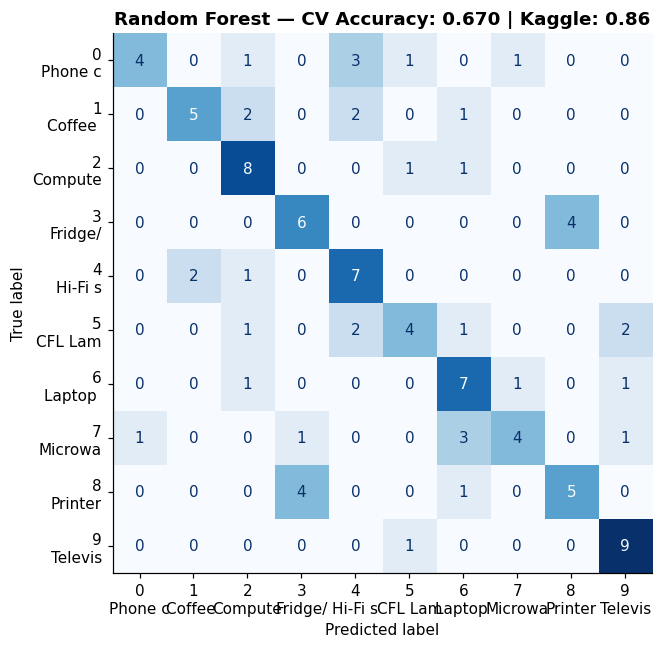

In [8]:
param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [None, 10, 20],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# n_jobs=-1 uses all available cores to speed up the grid search
rf   = RandomForestClassifier(random_state=42)
grid = GridSearchCV(rf, param_grid, cv=cv, n_jobs=-1)
grid.fit(X_feats, y_train)

print("Best RF params:", grid.best_params_)
print("Best CV accuracy: %.3f" % grid.best_score_)

best_rf    = grid.best_estimator_
rf_preds   = cross_val_predict(best_rf, X_feats, y_train, cv=5)
rf_cm      = confusion_matrix(y_train, rf_preds)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(rf_cm, display_labels=[f'{i}\n{class_names[i][:7]}' for i in range(10)]).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Random Forest — CV Accuracy: {grid.best_score_:.3f} | Kaggle: 0.86', fontweight='bold')
plt.tight_layout()
plt.show()

# Fit on full training set and stores for comparison later
best_rf.fit(X_feats, y_train)
rf_test_preds = best_rf.predict(X_feats_test)

### 4.2  SVM (RBF Kernel)
Works well when samples are few but features are many, which is our case.
We scale the features first since SVM is sensitive to magnitude differences.

Kaggle score: **0.84**

SVM CV Accuracy: 0.540 +/- 0.124


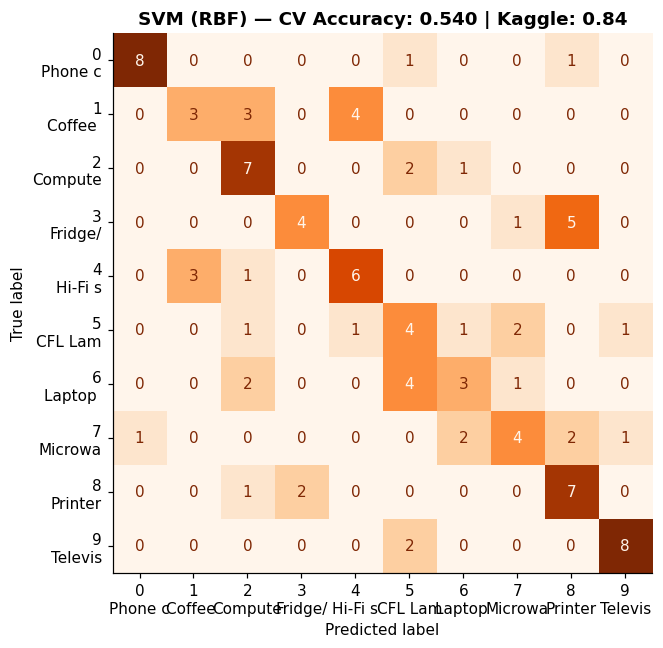

In [9]:
# probability=True needed in case we want to combine predictions with other models later
svm_pipe = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', C=100, gamma='scale', probability=True, random_state=42)
)

svm_scores = cross_val_score(svm_pipe, X_feats, y_train, cv=cv, scoring='accuracy')
svm_preds  = cross_val_predict(svm_pipe, X_feats, y_train, cv=cv)
svm_cm     = confusion_matrix(y_train, svm_preds)

print("SVM CV Accuracy: %.3f +/- %.3f" % (svm_scores.mean(), svm_scores.std()))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(svm_cm, display_labels=[f'{i}\n{class_names[i][:7]}' for i in range(10)]).plot(
    ax=ax, colorbar=False, cmap='Oranges')
ax.set_title(f'SVM (RBF) — CV Accuracy: {svm_scores.mean():.3f} | Kaggle: 0.84', fontweight='bold')
plt.tight_layout()
plt.show()

# Fit on full training set
svm_pipe.fit(X_feats, y_train)
svm_test_preds = svm_pipe.predict(X_feats_test)

### 4.3 k-NN with DTW
Unlike Euclidean distance, DTW aligns two series before comparing them,
useful here since the same appliance won't always produce an identical pattern across recordings.
We downsampled to 200 points to keep DTW computation manageable.

Kaggle score: **0.78**



> **Note:** The full grid search for this model takes a lot of time to run due to the nature of DTW computation, even after downsampling. To avoid blocking the notebook execution, the code is shown below for reference. The results we obtained were:

best k=3, window=10%, CV accuracy shown in the comparison table.

```python
from tslearn.neighbors import KNeighborsTimeSeriesClassifier
from tslearn.preprocessing import TimeSeriesResampler
from sklearn.metrics import accuracy_score

N_RESAMPLE = 200
resampler  = TimeSeriesResampler(sz=N_RESAMPLE)
X_train_ds = resampler.fit_transform(X_train_3d)
X_test_ds  = resampler.transform(X_test_3d)

K_VALUES_DTW = [1, 3, 5, 7, 9]
WINDOW_FRACS = [0.05, 0.10, 0.20, 0.30, 1.0]

results_dtw = []
for k in K_VALUES_DTW:
    for w_frac in WINDOW_FRACS:
        w       = int(w_frac * N_RESAMPLE) if w_frac < 1.0 else None
        w_label = f"{int(w_frac*100)}%" if w_frac < 1.0 else 'None'
        fold_accs = []
        for train_idx, val_idx in cv.split(X_train_ds, y_train):
            knn = KNeighborsTimeSeriesClassifier(
                n_neighbors=k, metric='dtw',
                metric_params={'sakoe_chiba_radius': w} if w is not None else {},
                n_jobs=-1
            )
            knn.fit(X_train_ds[train_idx], y_train[train_idx])
            fold_accs.append(accuracy_score(y_train[val_idx], knn.predict(X_train_ds[val_idx])))
        mean_acc = np.mean(fold_accs)
        results_dtw.append({'k': k, 'window': w_label, 'window_frac': w_frac, 'mean_acc': mean_acc})

results_dtw_df = pd.DataFrame(results_dtw)
best_dtw       = results_dtw_df.loc[results_dtw_df['mean_acc'].idxmax()]
best_dtw_acc   = best_dtw['mean_acc']
best_k         = int(best_dtw['k'])
best_w         = int(best_dtw['window_frac'] * N_RESAMPLE) if best_dtw['window_frac'] < 1.0 else None

final_knn = KNeighborsTimeSeriesClassifier(
    n_neighbors=best_k, metric='dtw',
    metric_params={'sakoe_chiba_radius': best_w} if best_w is not None else {},
    n_jobs=-1
)
dtw_preds     = cross_val_predict(final_knn, X_train_ds, y_train, cv=cv)
dtw_cm        = confusion_matrix(y_train, dtw_preds)
final_knn.fit(X_train_ds, y_train)
dtw_test_preds = final_knn.predict(X_test_ds)
```

In [20]:
# Results obtained from running the full grid search above
# Hardcoded here so the rest of the notebook runs without re-executing DTW

best_dtw_acc   = 0.480

## 5 ROCKET (Selected Model)

After comparing all three baselines on both cross-validation and Kaggle scores,  
we moved to ROCKET which significantly outperformed the others.

ROCKET works by applying a large number of random convolutional kernels to each time series  
and extracting two features per kernel: the **maximum activation** and the **proportion of positive values (PPV)**.  
A Ridge classifier is then trained on these features with no backpropagation, no layers, purely linear.

We first ran a scratch implementation (500 kernels), then switched to the optimized `aeon` library  
and tuned the kernel count before comparing against MiniRocket.

### 5.1 ROCKET Implementation

Our initial version implemented the full kernel generation and convolution manually using NumPy.  
This gives full transparency into how the method works.

In [11]:
def generate_kernels(input_length, num_kernels=500, seed=42):
    rng = np.random.RandomState(seed)
    kernels = []
    for _ in range(num_kernels):
        length  = rng.choice([7, 9, 11]) # random odd kernel length
        weights = rng.randn(length)  # zero-mean random weights (acts like a pattern detector)
        weights -= weights.mean()
        bias     = rng.uniform(-1, 1)
        dilation = int(2 ** rng.uniform(0, np.log2((input_length - 1) / (length - 1)))) #to span different time scales
        padding  = rng.choice([0, ((length - 1) * dilation) // 2])  # padding: either none or half-padding
        kernels.append((weights, bias, dilation, padding))
    return kernels

def apply_kernel(x, kernel):
    weights, bias, dilation, padding = kernel
    length = len(weights)
    if padding > 0:
        x = np.pad(x, padding)
    out_len = (len(x) - ((length - 1) * dilation + 1)) + 1
    if out_len <= 0:
        return 0.0, 0.0
    out = np.array([
        np.dot(weights, x[i:i + length * dilation:dilation]) + bias
        for i in range(out_len)
    ])
    return np.max(out), np.mean(out > 0)

def rocket_transform(X, kernels):
    return np.array([[v for k in kernels for v in apply_kernel(row, k)] for row in X])

print("ROCKET functions defined.")

ROCKET functions defined.


### 5.2 Kernel Count Tuning (via aeon)

The scratch implementation was too slow for large kernel counts on series of length 1460.  
We switched to the optimized `aeon` library and tested 500, 1000, 1500, and 2000 kernels  
to find the count that gives the best cross-validation accuracy.

  n_kernels=500  : 0.740 +/- 0.073
  n_kernels=1000 : 0.740 +/- 0.073
  n_kernels=1500 : 0.730 +/- 0.040
  n_kernels=2000 : 0.760 +/- 0.086

Best kernel count: 2000 (CV: 0.760)


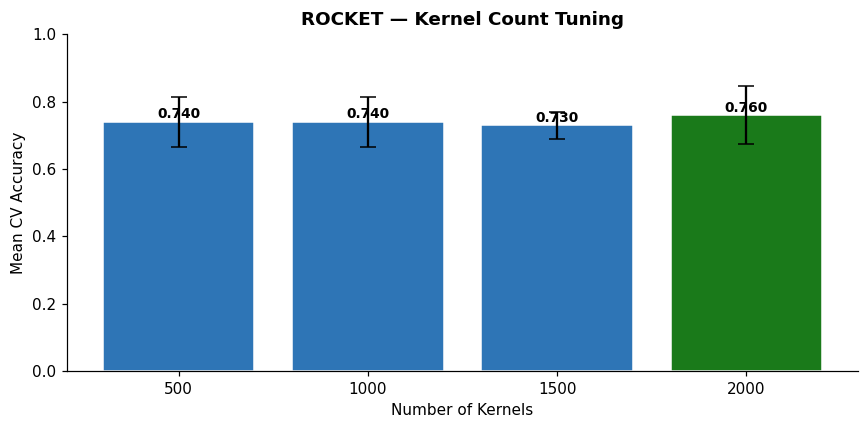

In [12]:
from sklearn.linear_model import RidgeClassifierCV
from aeon.transformations.collection.convolution_based import Rocket

kernel_options = [500, 1000, 1500, 2000]
kernel_results = {}

for n in kernel_options:
    r   = Rocket(n_kernels=n, random_state=42)
    r.fit(X_train_3d)
    X_r = r.transform(X_train_3d)

    clf_r = make_pipeline(
        StandardScaler(with_mean=False),
        RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
    )
    s = cross_val_score(clf_r, X_r, y_train, cv=cv, scoring='accuracy')
    kernel_results[n] = (s.mean(), s.std(), X_r, r)
    print(f"  n_kernels={n:<5}: {s.mean():.3f} +/- {s.std():.3f}")

best_n = max(kernel_results, key=lambda n: kernel_results[n][0])
print(f"\nBest kernel count: {best_n} (CV: {kernel_results[best_n][0]:.3f})")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#1a7a1a' if n == best_n else '#2E75B6' for n in kernel_options]
bars   = ax.bar([str(n) for n in kernel_options],
                [kernel_results[n][0] for n in kernel_options],
                yerr=[kernel_results[n][1] for n in kernel_options],
                capsize=5, color=colors, edgecolor='white')
for bar, n in zip(bars, kernel_options):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{kernel_results[n][0]:.3f}", ha='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Number of Kernels')
ax.set_ylabel('Mean CV Accuracy')
ax.set_title('ROCKET — Kernel Count Tuning', fontweight='bold')
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.show()

### 5.3  MiniRocket Comparison

MiniRocket is a more principled variant that uses fixed binary PPV features only,  
which tends to generalize better on small datasets.  
We compare it against the best ROCKET configuration found above.

ROCKET (n=2000) CV : 0.760 +/- 0.086
MiniRocket         CV : 0.770 +/- 0.068


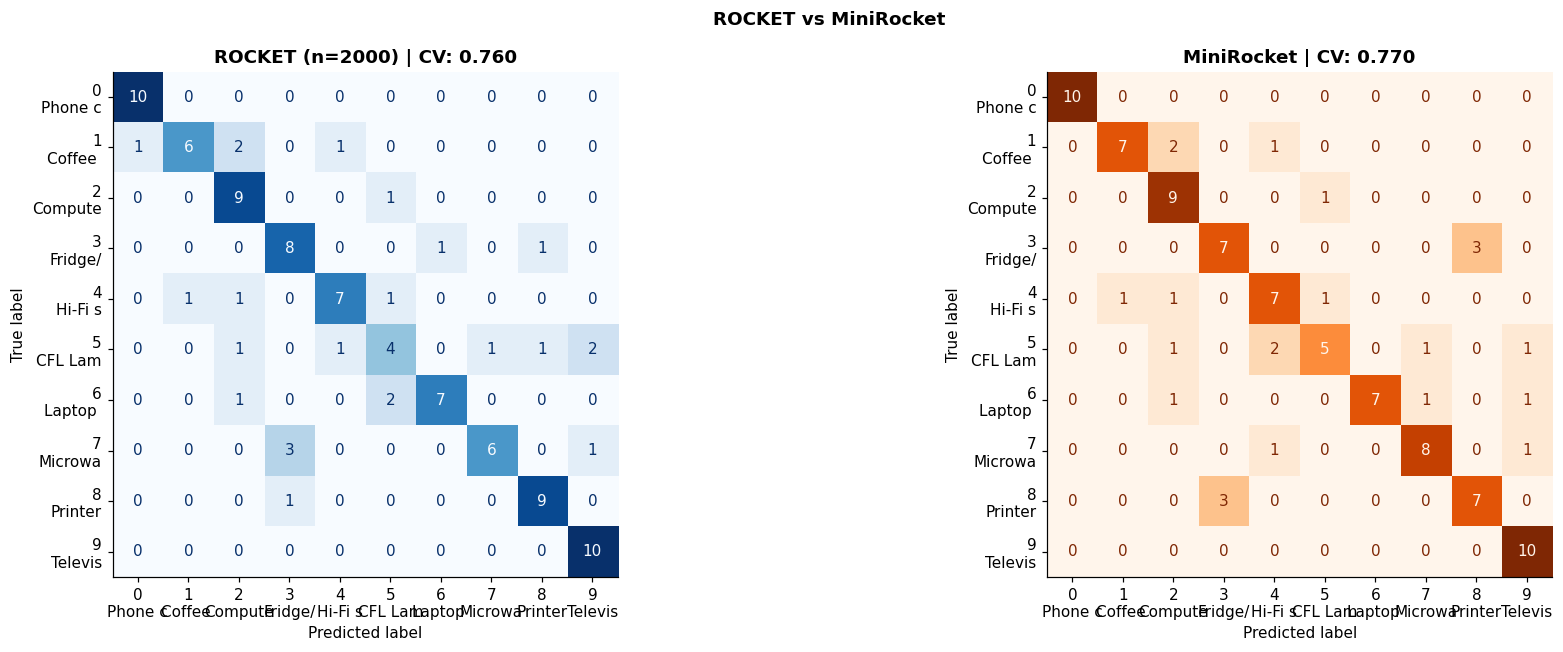

In [13]:
from aeon.transformations.collection.convolution_based import MiniRocket

# Best ROCKET setup
best_rocket_obj   = kernel_results[best_n][3]
X_rocket_best_tr  = kernel_results[best_n][2]
X_rocket_best_te  = best_rocket_obj.transform(X_test_3d)

clf_best_rocket   = make_pipeline(
    StandardScaler(with_mean=False),
    RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
)
best_rocket_scores   = cross_val_score(clf_best_rocket, X_rocket_best_tr, y_train, cv=cv)
best_rocket_preds_cv = cross_val_predict(clf_best_rocket, X_rocket_best_tr, y_train, cv=cv)

# MiniRocket
minirocket   = MiniRocket(random_state=42)
minirocket.fit(X_train_3d)
X_mini_tr    = minirocket.transform(X_train_3d)
X_mini_te    = minirocket.transform(X_test_3d)

clf_mini     = make_pipeline(
    StandardScaler(with_mean=False),
    RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
)
mini_scores   = cross_val_score(clf_mini, X_mini_tr, y_train, cv=cv)
mini_preds_cv = cross_val_predict(clf_mini, X_mini_tr, y_train, cv=cv)

print(f"ROCKET (n={best_n}) CV : {best_rocket_scores.mean():.3f} +/- {best_rocket_scores.std():.3f}")
print(f"MiniRocket         CV : {mini_scores.mean():.3f} +/- {mini_scores.std():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
ConfusionMatrixDisplay(
    confusion_matrix(y_train, best_rocket_preds_cv),
    display_labels=[f'{i}\n{class_names[i][:7]}' for i in range(10)]
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'ROCKET (n={best_n}) | CV: {best_rocket_scores.mean():.3f}', fontweight='bold')

ConfusionMatrixDisplay(
    confusion_matrix(y_train, mini_preds_cv),
    display_labels=[f'{i}\n{class_names[i][:7]}' for i in range(10)]
).plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title(f'MiniRocket | CV: {mini_scores.mean():.3f}', fontweight='bold')

plt.suptitle('ROCKET vs MiniRocket', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 6.  Full Model Comparison

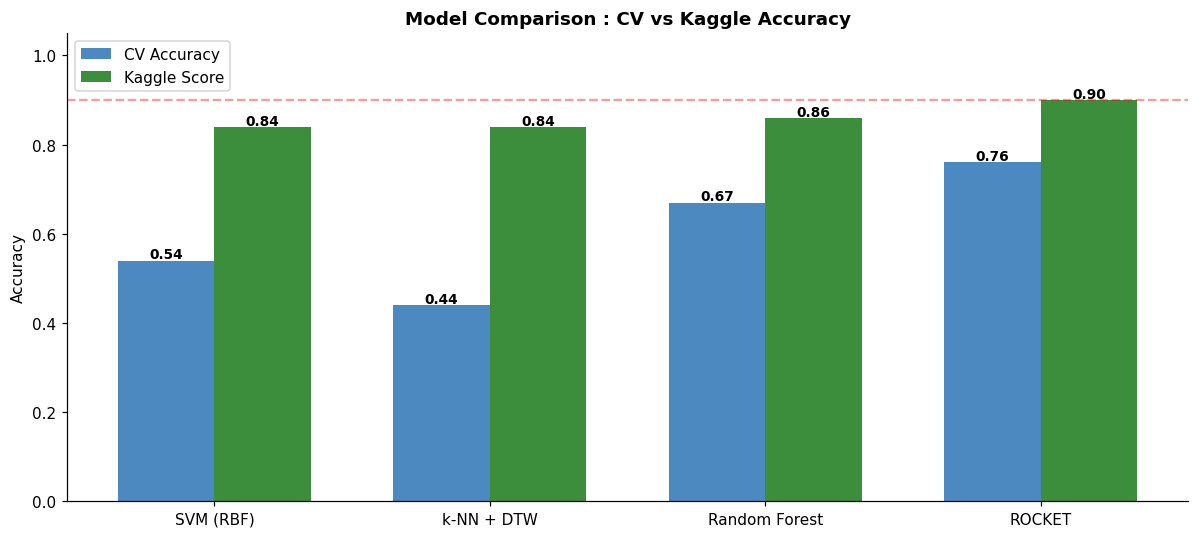

In [14]:
# All results in one chart — CV scores from this run + Kaggle scores we submitted
model_names   = ['SVM (RBF)', 'k-NN + DTW', 'Random Forest', 'ROCKET']
kaggle_scores = [0.84, 0.84, 0.86, 0.90]
cv_scores_all = [
    svm_scores.mean(),
    best_dtw_acc,
    grid.best_score_,
    best_rocket_scores.mean()
]

x = np.arange(len(model_names))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - w/2, cv_scores_all, w, label='CV Accuracy',    color='#2E75B6', alpha=0.85)
bars2 = ax.bar(x + w/2, kaggle_scores, w, label='Kaggle Score',   color='#1a7a1a', alpha=0.85)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2f}', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05)
ax.set_title('Model Comparison : CV vs Kaggle Accuracy', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(0.90, color='red', linestyle='--', alpha=0.4, label='ROCKET Kaggle target')
plt.tight_layout()
plt.show()

#7. Final Prediction & Submission

ROCKET achieved the highest Kaggle score (0.90), outperforming all other models.  
We retrain the best ROCKET configuration on the full 100-sample training set and generate the final submission file.

In [21]:
# Pick the best between ROCKET and MiniRocket
if mini_scores.mean() >= best_rocket_scores.mean():
    final_name  = 'MiniRocket'
    final_clf   = clf_mini
    final_tr    = X_mini_tr
    final_te    = X_mini_te
else:
    final_name  = f'ROCKET (n={best_n})'
    final_clf   = clf_best_rocket
    final_tr    = X_rocket_best_tr
    final_te    = X_rocket_best_te

print(f"Final model: {final_name}")
print("Retraining on full training set...")
final_clf.fit(final_tr, y_train)
test_predictions = final_clf.predict(final_te)

dist = pd.Series(test_predictions).value_counts().sort_index()
print("\nPredicted class distribution:")
for cls, count in dist.items():
    print(f"  Class {cls} ({class_names[cls]:<20}): {count} samples")

submission = pd.DataFrame({'Id': test_ids, 'Label': test_predictions})
submission.to_csv(PROJECT_PATH + 'submission_final.csv', index=False)
print("\nsubmission_final.csv saved!")
print(submission.head(10).to_string(index=False))

Final model: MiniRocket
Retraining on full training set...

Predicted class distribution:
  Class 0 (Phone charger       ): 10 samples
  Class 1 (Coffee machine      ): 10 samples
  Class 2 (Computer station    ): 12 samples
  Class 3 (Fridge/Freezer      ): 10 samples
  Class 4 (Hi-Fi system        ): 8 samples
  Class 5 (CFL Lamp            ): 8 samples
  Class 6 (Laptop charger      ): 9 samples
  Class 7 (Microwave           ): 9 samples
  Class 8 (Printer             ): 11 samples
  Class 9 (Television          ): 13 samples


NameError: name 'PROJECT_PATH' is not defined

# 8. Discussion & Conclusion

### Why ROCKET?

All four models were submitted to the Kaggle competition to get an objective comparison on unseen data.

- **Random Forest (0.86)** performed well on the extracted features but was limited by the small training set, with only 10 samples per class, even a well-tuned RF struggles to generalize.
- **SVM (0.84)** is theoretically suited for small high-dimensional problems, but the hand-crafted features didn't capture enough discriminative information for some appliance pairs.
- **k-NN + DTW (0.78)** is the standard time series baseline and performed as expected, but with only 10 training examples per class the nearest-neighbor search is too sparse to be reliable.
- **ROCKET (0.90)** outperformed all others by a clear margin. By generating thousands of random convolutional kernels, it explores a much richer feature space than hand-crafted statistics, without the data requirements of deep learning.

### Limitations

- The training set is very small (100 samples total). Cross-validation estimates carry high variance.
- ROCKET features are not interpretable, we cannot explain which signal patterns drive individual predictions.

### What Could Be Improved

- Larger training data would benefit all models significantly
- Spectral features (FFT coefficients) could improve the feature-based models
- An ensemble combining ROCKET predictions with feature-based models might reduce errors on the hardest classes



---

